In [16]:
# ============================================================
# Cell 0 — Parameters
# ============================================================
"""
Parameters from Table I of:
Gioannini & Rossetti, "Time-Domain Traveling Wave Model of Quantum Dot DFB Lasers"
IEEE J. Sel. Top. Quantum Electron., Vol. 17, No. 5, 2011

All values are in SI units unless noted.
"""

import numpy as np
import os

# ── Physical constants ────────────────────────────────────────────────────────
q        = 1.602176634e-19   # elementary charge (C)
hbar     = 1.054571817e-34   # reduced Planck constant (J·s)
kB       = 1.380649e-23      # Boltzmann constant (J/K)
c0       = 2.997924580e8     # speed of light in vacuum (m/s)
eps0     = 8.854187817e-12   # vacuum permittivity (F/m)
m0       = 9.1093837015e-31  # free electron mass (kg)
T        = 300.0             # room temperature (K)

# ── Material parameters ───────────────────────────────────────────────────────
h_w      = 5e-9              # QD layer height (m)
eta      = 3.3445            # effective refractive index (dimensionless)
N_l      = 8                 # number of QD layers
N_D      = 5.9e14            # QD surface density (m⁻²)  [5.9×10¹⁰ cm⁻² → ×10⁴]
N_groups = 51                # number of QD groups for inhomogeneous broadening

# State degeneracies: D_m for m = ES2, ES1, GS
D = {
    'ES2': 6,
    'ES1': 4,
    'GS':  2,
}

hbar_Gamma = 7e-3 * q       # homogeneous linewidth (J)  [7 meV → ×q]
Gamma      = hbar_Gamma / hbar  # dephasing rate (rad/s)

Delta_E    = 38e-3 * q      # FWHM of inhomogeneous broadening (J)  [38 meV]

# Dipole matrix elements A_m  (cm³·eV → m³·J)
# 1 cm³·eV = 1e-6 m³ × 1.602e-19 J  →  multiply by 1e-6 * q
A = {
    'ES1': 1.26e-20 * 1e-6 * q,   # m³·J
    'GS':  2.03e-20 * 1e-6 * q,   # m³·J
}

# SCH diffusion/transport times (s)
tau_c_e_W  = 1.2e-12        # electron transport time across SCH (s)
tau_c_h_W  = 23.2e-12       # hole transport time across SCH (s)

tau_e_e_W  = 0.0492e-12

# Electron relaxation times τ_c^{e,m} for m = ES2, ES1, GS (s)
tau_c_e = {
    'ES2': 3e-12,
    'ES1': 2e-12,
    'GS':  2e-12,
}

tau_e_e_im = {
    'ES2': 6.15e-12,
    'ES1': 7.99e-12,
    'GS':  10.63e-12,
}

# Interband recombination time in the WL (s)
tau_r_e_W  = 100e-12

tau_e_h_qd = 1.46E-12

# Spontaneous emission recombination times τ_Sp^m for m = ES2, ES1, GS (s)
tau_Sp = {
    'ES2': 2.8e-9,
    'ES1': 2.8e-9,
    'GS':  2.8e-9,
}

# Auger recombination times τ_Au^m for m = ES2, ES1, GS (s)
tau_Au = {
    'ES2': 110e-12,
    'ES1': 275e-12,
    'GS':  660e-12,
}

# Interband transition energies hbar*omega_im for i=(N+1)/2 (central group)
# m = ES2, ES1, GS  (eV → J)
hbar_omega = {
    'ES2': 1.098 * q,   # J
    'ES1': 1.042 * q,
    'GS':  0.959 * q,   # J
}

# Reference (Bragg) angular frequency — set to GS transition of central group
omega_0 = hbar_omega['GS'] / hbar   # rad/s

# Intrinsic waveguide losses (m⁻¹)  [1.5 cm⁻¹ → ×100]
alpha_i  = 1.5e2

# ── Device parameters ─────────────────────────────────────────────────────────
W        = 2.2e-6            # ridge equivalent width (m)
h_SCH    = 430e-9            # SCH height (m)
r0_sq    = 0.90              # power reflectivity at z=0  (HR facet)
rL_sq    = 0.00              # power reflectivity at z=L  (AR facet)
L        = 400e-6            # total cavity length (m)
k_DFB    = 40e2              # grating coupling coefficient (m⁻¹)  [40 cm⁻¹]

# ── Derived / assumed parameters ──────────────────────────────────────────────
# Internal quantum efficiency (50% per [7] in the paper)
eta_i    = 0.50

# Field confinement factor in QD layers (lateral × transverse)
# Not given in table; typical value for this ridge geometry
Gamma_xy = 0.03             # (dimensionless) — approximate; tune to match gain

# Optical confinement factor of the SCH
Gamma_xy_SCH = 0.3          # (dimensionless) — approximate

# ── QD group energies (Gaussian inhomogeneous distribution) ──────────────────
# Groups indexed i = 0 ... N_groups-1; central group i_c = (N_groups-1)//2
sigma    = Delta_E / (2 * np.sqrt(2 * np.log(2)))   # Gaussian sigma (J)
i_c      = (N_groups - 1) // 2                       # index of central group
i_arr    = np.arange(N_groups)                        # 0 … 50

# Energy offset of each group from central group (evenly spaced, ±3σ span)
# Total span set to 4×FWHM to capture >99% of distribution
E_span   = 4 * Delta_E                               # total span (J)
dE       = E_span / (N_groups - 1)                   # spacing between groups

# GS transition energy for each group
E_GS_i   = hbar_omega['GS'] + (i_arr - i_c) * dE    # (J), shape (N_groups,)

# ES1 and ES2 energies follow same offset as GS (rigid shift of whole spectrum)
E_ES1_i  = hbar_omega['ES1'] + (i_arr - i_c) * dE
E_ES2_i  = hbar_omega['ES2'] + (i_arr - i_c) * dE

# Gaussian weighting G_i (normalised so sum = 1)
G_i      = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i     /= G_i.sum()

# ── Valence-band confined-state energies (hole states) ───────────────────────
# Five hole confined states (GS, ES1…ES4) equally separated by 12 meV
# (stated in Section III-A of the paper)
delta_h  = 12e-3 * q        # hole level separation (J)
# Hole state energies relative to WL (negative = below WL continuum)
# Labelled GS=0, ES1=1, ES2=2, ES3=3, ES4=4
n_hole_states = 5
E_hole   = np.array([-k * delta_h for k in range(n_hole_states)])  # (J)
D_hole   = np.array([2, 4, 6, 8, 10])  # degeneracy (assumed 2*(k+1))

# ── Collect everything into a single dictionary ───────────────────────────────
params = {
    # Physical constants
    'q':            q,
    'hbar':         hbar,
    'kB':           kB,
    'c0':           c0,
    'eps0':         eps0,
    'm0':           m0,
    'T':            T,

    # Material
    'h_w':          h_w,
    'eta':          eta,
    'N_l':          N_l,
    'N_D':          N_D,
    'N_groups':     N_groups,
    'D':            D,
    'hbar_Gamma':   hbar_Gamma,
    'Gamma':        Gamma,
    'Delta_E':      Delta_E,
    'A':            A,
    'tau_c_e_W':    tau_c_e_W,
    'tau_e_e_W':    tau_e_e_W,
    'tau_c_h_W':    tau_c_h_W,
    'tau_e_h_qd':   tau_e_h_qd,
    'tau_c_e':      tau_c_e,
    'tau_e_e_im':   tau_e_e_im,
    'tau_r_e_W':    tau_r_e_W,
    'tau_Sp':       tau_Sp,
    'tau_Au':       tau_Au,
    'hbar_omega':   hbar_omega,
    'omega_0':      omega_0,
    'alpha_i':      alpha_i,

    # Device
    'W':            W,
    'h_SCH':        h_SCH,
    'r0_sq':        r0_sq,
    'rL_sq':        rL_sq,
    'L':            L,
    'k_DFB':        k_DFB,

    # Derived / assumed
    'eta_i':        eta_i,

    'Gamma_xy':     Gamma_xy,
    'Gamma_xy_SCH': Gamma_xy_SCH,

    # QD group arrays (length N_groups)
    'i_arr':        i_arr,
    'G_i':          G_i,
    'E_GS_i':       E_GS_i,
    'E_ES1_i':      E_ES1_i,
    'E_ES2_i':      E_ES2_i,
    'dE':           dE,

    # Hole confined states
    'n_hole_states': n_hole_states,
    'E_hole':       E_hole,
    'D_hole':       D_hole,
    'delta_h':      delta_h,
}


if __name__ == '__main__':
    print("=== QD-DFB Laser Parameters (SI units) ===\n")
    for k, v in params.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s}: array shape {v.shape}, "
                  f"range [{v.min():.4g}, {v.max():.4g}]")
        elif isinstance(v, dict):
            print(f"  {k:20s}: {v}")
        else:
            print(f"  {k:20s}: {v:.6g}" if isinstance(v, float) else
                  f"  {k:20s}: {v}")

=== QD-DFB Laser Parameters (SI units) ===

  q                   : 1.60218e-19
  hbar                : 1.05457e-34
  kB                  : 1.38065e-23
  c0                  : 2.99792e+08
  eps0                : 8.85419e-12
  m0                  : 9.10938e-31
  T                   : 300
  h_w                 : 5e-09
  eta                 : 3.3445
  N_l                 : 8
  N_D                 : 5.9e+14
  N_groups            : 51
  D                   : {'ES2': 6, 'ES1': 4, 'GS': 2}
  hbar_Gamma          : 1.12152e-21
  Gamma               : 1.06349e+13
  Delta_E             : 6.08827e-21
  A                   : {'ES1': 2.0187425588399996e-45, 'GS': 3.25241856702e-45}
  tau_c_e_W           : 1.2e-12
  tau_e_e_W           : 4.92e-14
  tau_c_h_W           : 2.32e-11
  tau_e_h_qd          : 1.46e-12
  tau_c_e             : {'ES2': 3e-12, 'ES1': 2e-12, 'GS': 2e-12}
  tau_e_e_im          : {'ES2': 6.15e-12, 'ES1': 7.99e-12, 'GS': 1.063e-11}
  tau_r_e_W           : 1e-10
  tau_Sp            

In [17]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [18]:

# ============================================================
# Cell 2 — Fixed arrays and constants
#           Assumes `params`, `i_arr`, `i_c`, `dE`, `sigma`
#           are already defined in your environment.
# ============================================================

N   = 51
n_m = 3   # [0] GS  [1] ES1  [2] ES2

# Inhomogeneous broadening distribution — shape (n_m, N)
G_i  = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i /= G_i.sum()
G_i  = np.stack([G_i, G_i, G_i], axis=0)

# Degeneracy factors — shape (n_m, N)
D_m = np.array([2, 4, 6])[:, None] * np.ones((n_m, N))
A_m = np.array([params['A']['GS'], params['A']['ES1']])[:, None] * np.ones((2, N))

# Hole sub-band degeneracies and energies
D_m_h   = np.array([2, 4, 6, 8, 10], dtype=int)
delta_E = 12e-3 * 1.6e-19                           # [J]
E_h_m   = np.array([5, 4, 3, 2, 1]) * delta_E
E_h_WL  = 0.0

kBT = params['kB'] * params['T']                    # thermal energy [J]

# Auger and spontaneous-emission lifetimes — shape (n_m, N)
auger_lifetimes = np.zeros((n_m, N))
auger_lifetimes[0, :] = params['tau_Au']['GS']
auger_lifetimes[1, :] = params['tau_Au']['ES1']
auger_lifetimes[2, :] = params['tau_Au']['ES2']

sp_lifetimes = np.zeros((n_m, N))
sp_lifetimes[0, :] = params['tau_Sp']['GS']
sp_lifetimes[1, :] = params['tau_Sp']['ES1']
sp_lifetimes[2, :] = params['tau_Sp']['ES2']

omegahbar = np.array([params['E_GS_i']/params['hbar'],params['E_ES1_i']/params['hbar']],)

delta_E_sch_w   = 95.1 # UNCERTAIN - CLAUDE suggests 120 y
delta_E_h_sch_w = 154 # UNCERTAIN - CLAUDE suggests 150  z
delta_e_w_es2   = 36.9 # UNCERTAIN - CLAUDE suggests 52  x
delta_e_es2_es1 = 44 #CERTAIN
delta_e_es1_gs  = 71 #CERTAOM 


In [19]:
# ============================================================
# Cell 3 — Helper functions
#           These rely on kBT, E_h_m, E_h_WL, D_m_h, params
#           defined in Cell 2.
# ============================================================

def fun(EF, N_h_qd, params, m_h_w):
    """Charge-neutrality equation for holes (energies in Joules)."""
    wl_term = (m_h_w* 9.11E-31 * params['N_l'] * kBT
               / (np.pi * params['hbar']**2)
               ) * np.logaddexp(0.0, (E_h_WL - EF) / kBT)
    exponent      = (EF - E_h_m) / kBT
    confined_term = np.sum(params['N_l'] * params['N_D'] * D_m_h / (1.0 + np.exp(exponent)))
    return confined_term + wl_term - N_h_qd


def fun_eV(EF_eV, N_h_qd, params, m_h_w):
    """Wrapper for fun() that accepts EF in electronvolts."""
    return fun(EF_eV * 1.6e-19, N_h_qd, params, m_h_w)


def fermi(E, EF):
    """Fermi–Dirac occupation probability."""
    return 1.0 / (1.0 + np.exp((EF - E) / kBT))

def gain(omega, rho_e_im, rho_hmat, params):
    gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[:2]*D_m[:2]*A_m*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(omega-omegahbar))
                     * (rho_e_im[:2]+rho_hmat[:2]-1)))
    return gain

def gain_index(omega, rho_e_im, rho_hmat, params, index):

    if index == 0 or index ==1:

        gain = (params['Gamma_xy']/params['h_w']*params['N_D']
                * np.sum(G_i[index]*D_m[index]*A_m[index]*1j/params['hbar']/np.pi
                        / (params['Gamma']+1j*(omega-omegahbar[index]))
                        * (rho_e_im[index]+rho_hmat[index]-1)))
    if index == 2:
       gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[0]*6*A_m[1]*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(params['E_ES2_i']/params['hbar']))
                     * (rho_e_im[1]+rho_hmat[1]-1))) 
    return gain

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

t_end = 20E-9
tstep = 30e-15
J = 7E-3/(400E-6*2.2E-6)
initial_values = {
    'n_e_sch' : 0.0,
    'n_e_w'   : 0.0,
    'n_e_im'  : np.zeros((n_m, N)),   # shape (n_m, N)
    'n_h_sch' : 0.0,
    'n_hq_qd' : 1e6,                 # initial hole population in QD reservoir
}
threshold = 0.01
delta_E_sch_w = 95.1
delta_E_h_sch_w = 154
m_e_sch = 0.063
m_e_w = 0.03
m_h_sch = 0.5
m_h_w = 0.45
rt_ev = 25.9
delta_e_w_es2 = 286 - delta_E_sch_w - delta_E_h_sch_w

DOS_sch   = 2*((2*np.pi*m_e_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
DOS_w     = ((m_e_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))
DOS_sch_h = 2*((2*np.pi*m_h_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
DOS_w_h   = ((m_h_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))

tau_e_e_W   = DOS_w*params['N_l']/DOS_sch/params['h_SCH']*np.exp(delta_E_sch_w/rt_ev)*params['tau_c_e_W']
tau_e_h_qd  = 1/params['h_SCH']*DOS_w_h*params['N_l']/DOS_sch_h*np.exp(delta_E_h_sch_w/rt_ev)*params['tau_c_h_W']
tau_e_e_ES1 = 4/6*np.exp(delta_e_es2_es1/rt_ev)*params['tau_c_e']['ES1']
tau_e_e_ES2 = 6*params['N_D']/DOS_w*np.exp(delta_e_w_es2/rt_ev)*params['tau_c_e']['ES2']
tau_e_e_GS  = 2/4*np.exp(delta_e_es1_gs/rt_ev)*params['tau_c_e']['GS']

# Unpack initial values
n_e_sch = float(initial_values['n_e_sch'])
n_e_w   = float(initial_values['n_e_w'])
n_e_im  = initial_values['n_e_im'].copy().astype(float)
n_h_sch = float(initial_values['n_h_sch'])
n_hq_qd = float(initial_values['n_hq_qd'])

n_steps   = int(np.round(t_end / tstep))
milestone = max(1, n_steps // 10)

# --- history buffers for plotting population vs time ---
t_hist       = []
n_e_sch_hist = []
n_e_w_hist   = []
n_h_sch_hist = []
n_hq_qd_hist = []
n_e_gs_hist  = []   # QD ground-state electrons, summed over ensembles
n_e_es1_hist = []   # QD ES1 electrons, summed over ensembles
n_e_es2_hist = []   # QD ES2 electrons, summed over ensembles

for step in range(n_steps):
    if step % milestone == 0:
        pct = 100 * step / n_steps
        print(f"  {pct:5.1f}%  t = {step * tstep * 1e9:.3f} ns")

    rho_e_im = n_e_im / (params['N_l'] * params['N_D'] * G_i * D_m)

    EF_lo_eV = (E_h_m[0] - 100 * kBT) / 1.6e-19
    EF_hi_eV = (E_h_WL  + 100 * kBT)  / 1.6e-19
    sol      = root_scalar(fun_eV, args=(n_hq_qd, params, m_h_w),
                            bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
    root_J   = sol.root * 1.6e-19

    rho_h_m   = fermi(E_h_m, root_J)
    rho_h_mat = np.zeros((n_e_im.shape[0], n_e_im.shape[1]))
    rho_h_mat[0, :] = rho_h_m[0]
    rho_h_mat[1, :] = rho_h_m[1]
    rho_h_mat[2, :] = rho_h_m[2]

    R_aug_im = n_e_im * rho_e_im * rho_h_mat / auger_lifetimes
    R_sp_im  = n_e_im * rho_h_mat / sp_lifetimes

    dn_e_sch = (params['eta_i']*J/params['q']
                - n_e_sch/params['tau_c_e_W']
                + n_e_w/tau_e_e_W)

    dn_e_w = (n_e_sch/params['tau_c_e_W']
                - n_e_w/tau_e_e_W
                - n_e_w/params['tau_r_e_W']
                - np.sum(G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:]))
                + np.sum(n_e_im[2,:]/tau_e_e_ES2))

    dn_i_e_es2 = (G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:])
                    - n_e_im[2,:]/tau_e_e_ES2
                    - R_sp_im[2,:] - R_aug_im[2,:]
                    - n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                    + n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:]))

    dn_i_e_es1 = (n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                    - n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:])
                    - R_aug_im[1,:]
                    - n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                    + n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                    - R_sp_im[1,:])

    dn_i_e_gs = (n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                    - n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                    - R_aug_im[0,:] - R_sp_im[0,:])

    dn_h_sch = (params['eta_i']*J/params['q']
                - n_h_sch/params['tau_c_h_W']
                + n_hq_qd/tau_e_h_qd)

    dn_h_qd  = (n_h_sch/params['tau_c_h_W']
                - n_hq_qd/tau_e_h_qd
                - np.sum(R_aug_im) - np.sum(R_sp_im)
                - n_e_w / params['tau_r_e_W'])

    rel_changes = [
        abs(dn_e_sch) / (n_e_sch + 1e-20),
        abs(dn_e_w)   / (n_e_w   + 1e-20),
        abs(dn_h_sch) / (n_h_sch + 1e-20),
        abs(dn_h_qd)  / (n_hq_qd + 1e-20),
        np.max(abs(dn_i_e_gs)  / (n_e_im[0, :] + 1e-20)),
        np.max(abs(dn_i_e_es1) / (n_e_im[1, :] + 1e-20)),
        np.max(abs(dn_i_e_es2) / (n_e_im[2, :] + 1e-20)),
    ]

    n_e_sch      += dn_e_sch    * tstep
    n_e_w        += dn_e_w      * tstep
    n_e_im[0, :] += dn_i_e_gs  * tstep
    n_e_im[1, :] += dn_i_e_es1 * tstep
    n_e_im[2, :] += dn_i_e_es2 * tstep
    n_h_sch      += dn_h_sch    * tstep
    n_hq_qd      += dn_h_qd    * tstep

    # record populations for this timestep
    t_hist.append((step + 1) * tstep)
    n_e_sch_hist.append(n_e_sch)
    n_e_w_hist.append(n_e_w)
    n_h_sch_hist.append(n_h_sch)
    n_hq_qd_hist.append(n_hq_qd)
    n_e_gs_hist.append(np.sum(n_e_im[0, :]))
    n_e_es1_hist.append(np.sum(n_e_im[1, :]))
    n_e_es2_hist.append(np.sum(n_e_im[2, :]))

    if max(rel_changes) < threshold:
        print(f"  Converged at step {step}  (t = {step * tstep * 1e9:.3f} ns)")
        break

print("  Done.")

# Return only the final scalar/array state — no history
final_state = {
    'n_e_sch': n_e_sch,
    'n_e_w':   n_e_w,
    'n_e_im':  n_e_im,        # shape (n_m_loc, N_loc)
    'n_h_sch': n_h_sch,
    'n_hq_qd': n_hq_qd,
}
t_final = step * tstep

# --- plot populations vs time up to convergence ---
t_hist_ns = np.array(t_hist) * 1e9

    0.0%  t = 0.000 ns
   10.0%  t = 2.000 ns
   20.0%  t = 4.000 ns
   30.0%  t = 6.000 ns
   40.0%  t = 8.000 ns
   50.0%  t = 10.000 ns
   60.0%  t = 12.000 ns
  Converged at step 440269  (t = 13.208 ns)
  Done.


In [21]:
# --- save population history to CSV ---
import csv
 
export_path = 'population_history.csv'
with open(export_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['t', 'n_e_sch', 'n_e_w', 'n_h_sch', 'n_hq_qd',
                      'n_e_gs', 'n_e_es1', 'n_e_es2'])
    for i in range(len(t_hist)):
        writer.writerow([
            t_hist[i], n_e_sch_hist[i], n_e_w_hist[i], n_h_sch_hist[i],
            n_hq_qd_hist[i], n_e_gs_hist[i], n_e_es1_hist[i], n_e_es2_hist[i],
        ])
print(f"  Population history saved to: {export_path}")

  Population history saved to: population_history.csv


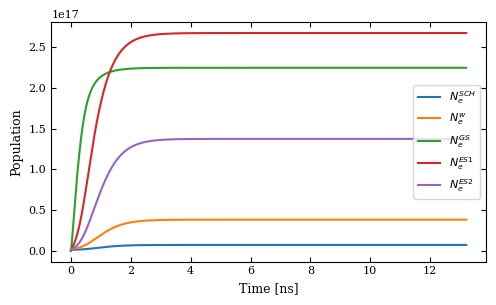

In [23]:
# --- separate cell: load population_history.csv and plot it ---
import csv

# ── Figure sizing (golden ratio, single-column width) ──────────────────────
GOLDEN_RATIO = 1.618
FIG_WIDTH_IN = 5          # comfortably under the 6.3 in max
FIG_HEIGHT_IN = FIG_WIDTH_IN / GOLDEN_RATIO

# ── Publication-style rcParams ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,   # embed fonts properly (editable text in PDF)
    "ps.fonttype": 42,
})

import numpy as np
import matplotlib.pyplot as plt

export_path = 'population_history.csv'

t_hist       = []
n_e_sch_hist = []
n_e_w_hist   = []
n_h_sch_hist = []
n_hq_qd_hist = []
n_e_gs_hist  = []
n_e_es1_hist = []
n_e_es2_hist = []

with open(export_path, 'r', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        t_hist.append(float(row['t']))
        n_e_sch_hist.append(float(row['n_e_sch']))
        n_e_w_hist.append(float(row['n_e_w']))
        n_h_sch_hist.append(float(row['n_h_sch']))
        n_hq_qd_hist.append(float(row['n_hq_qd']))
        n_e_gs_hist.append(float(row['n_e_gs']))
        n_e_es1_hist.append(float(row['n_e_es1']))
        n_e_es2_hist.append(float(row['n_e_es2']))

t_hist_ns    = np.array(t_hist) * 1e9
n_e_sch_hist = np.array(n_e_sch_hist)
n_e_w_hist   = np.array(n_e_w_hist)
n_h_sch_hist = np.array(n_h_sch_hist)
n_hq_qd_hist = np.array(n_hq_qd_hist)
n_e_gs_hist  = np.array(n_e_gs_hist)
n_e_es1_hist = np.array(n_e_es1_hist)
n_e_es2_hist = np.array(n_e_es2_hist)

plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))
plt.plot(t_hist_ns, n_e_sch_hist/40E-3, label=r'$N_e^{SCH}$')
plt.plot(t_hist_ns, n_e_w_hist/40E-3,   label=r'$N_e^w$')
#plt.plot(t_hist_ns, n_h_sch_hist/40E-3, label='n_h_sch')
#plt.plot(t_hist_ns, n_hq_qd_hist/40E-3, label='n_hq_qd')
plt.plot(t_hist_ns, n_e_gs_hist/40E-3,  label=r'$N_e^{GS}$')
plt.plot(t_hist_ns, n_e_es1_hist/40E-3, label=r'$N_e^{ES1}$')
plt.plot(t_hist_ns, n_e_es2_hist/40E-3, label=r'$N_e^{ES2}$')

plt.xlabel('Time [ns]')
plt.ylabel('Population')
plt.yscale('linear')
#plt.title('Carrier population vs. time')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\Methods & Results\population_comparison.pdf')
plt.show()